# Upper Confidence Bound (UCB) Algorithm

### Scenario: Advertising Campaign with 10,000 users and 10 ads
- Imagine you are running an online advertising campaign for 10 different ads (Ad 1 to Ad 10). Your goal is to determine which ad performs best (i.e., gets the most clicks) and display it more often to maximize engagement.

### How the UCB Algorithm Works

1. #### Objective:
    - Used in Reinforcement Learning to solve the multi-armed bandit problem, where you aim to balance between exploration and exploitation in an online advertising context.

    - The UCB algorithm balances two objectives:
        1. Exploration: Test less frequently clicked ads to see if they can perform better.

        2. Exploitation: Focus on ads that have already shown good performance (deterministic).

2. #### Rounds:
    - Each round represents one user visiting the website or app.

    - The UCB algorithm selects one ad to show to the user based on past performance and potential future performance (confidence bounds).

3. #### Example:
    - You start with no knowledge about any ad's performance.

    - The algorithm first shows all ads once (exploration phase).

    - As data is collected (clicks vs. impressions), the algorithm computes which ad has the best Upper Confidence Bound and prioritizes showing that ad (exploitation phase).

### Difference from Thompson Sampling Algorithm:
- Thompson Sampling: Uses a probability distribution to sample the best ad.

- UCB: Uses a confidence interval to estimate the best ad.

- It is detrministic, as it does not need any prior knowledge about the ads' performance.

- Requires update at every round.

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import pandas as pd

## Loading the dataset

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')
dataset

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,0,0,1,0,0,0,0,1,0,0
9996,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0
9998,1,0,0,0,0,0,0,1,0,0


## Implementing UCB

In [13]:
import math

N = dataset.shape[0] # 'N = number of rounds (users/user interactions) in the dataset' -> 10,000 rounds
# N = dataset.shape[0] - 5000 # Number of rounds (users/user interactions) in the dataset' -> 5,000 rounds
# N = dataset.shape[0] - 9000 # Number of rounds (users/user interactions) in the dataset' -> 1,000 rounds
# N = dataset.shape[0] - 9500 # UCB cannot find the best ad in 500 rounds.
ads = dataset.shape[1] # 'ads = number of columns (ads) in the dataset'
ads_selected = [] # 'ads_selected = list to store the selected ads'
numbers_of_selected_ads = [0] * ads # 'number_of_selected_ads = list to store the number of times each ad was selected'
sums_of_rewards = [0] * ads # 'sums_of_rewards = list to store the sum of rewards for each ad'
total_reward = 0 # 'total_reward = sum of all rewards '

for n in range(0, N): # 'N = number of rounds in the dataset'
    ad = 0
    max_upper_bound = 0 # 'max_upper_bound = 0 to store the maximum upper bound'
    for i in range(0, ads): # 'ads = number of columns (ads) in the dataset'
        if (numbers_of_selected_ads[i] > 0):
            average_reward = sums_of_rewards[i] / numbers_of_selected_ads[i] # 'STEP 1: The Average_reward -> sum of rewards for each ad divided by the number of times it was clicked'
            delta_i = np.sqrt(3/2 * np.log(n + 1) / numbers_of_selected_ads[i]) # 'STEP 2: The Confidence Interval -> delta_i = square root of (3/2 * log(n + 1) / number of times ad was clicked)'
            upper_bound = average_reward + delta_i # 'The Upper Confidence Bound'
        else:
            upper_bound = 1e400 # '1 x 10^400' = a large number to ensure that the ad is clicked if it's not clicked before.
        if upper_bound > max_upper_bound: # 'STEP 3: If ad was not clicked before, set upper_bound to a large value'
            max_upper_bound = upper_bound
            ad = i # 'STEP 3 completed: The ad with the maximum upper bound is selected'
    ads_selected.append(ad) # All the ads selected over the rounds (users).
    numbers_of_selected_ads[ad] += 1
    reward = dataset.values[n, ad]
    sums_of_rewards[ad] = sums_of_rewards[ad] + reward
    total_reward += reward

In [14]:
ads_selected

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 0,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 8,
 9,
 0,
 8,
 1,
 2,
 3,
 4,
 5,
 6,
 6,
 7,
 7,
 7,
 9,
 7,
 0,
 6,
 8,
 1,
 2,
 3,
 4,
 4,
 4,
 4,
 4,
 5,
 9,
 7,
 0,
 0,
 6,
 8,
 4,
 0,
 7,
 1,
 1,
 2,
 3,
 5,
 9,
 4,
 1,
 6,
 8,
 0,
 7,
 2,
 3,
 5,
 9,
 4,
 1,
 6,
 8,
 0,
 7,
 7,
 7,
 7,
 7,
 7,
 4,
 2,
 3,
 5,
 9,
 1,
 6,
 8,
 0,
 0,
 7,
 0,
 4,
 1,
 6,
 8,
 2,
 3,
 5,
 9,
 7,
 0,
 4,
 4,
 4,
 7,
 7,
 7,
 7,
 1,
 6,
 8,
 2,
 3,
 5,
 9,
 0,
 7,
 7,
 4,
 7,
 7,
 7,
 1,
 6,
 8,
 0,
 4,
 4,
 2,
 3,
 5,
 9,
 4,
 7,
 0,
 7,
 1,
 1,
 1,
 6,
 6,
 6,
 6,
 6,
 8,
 4,
 2,
 3,
 5,
 9,
 7,
 7,
 7,
 0,
 6,
 4,
 1,
 1,
 1,
 8,
 7,
 2,
 3,
 5,
 9,
 4,
 0,
 1,
 1,
 1,
 6,
 7,
 8,
 4,
 1,
 2,
 3,
 5,
 9,
 0,
 6,
 7,
 8,
 4,
 7,
 1,
 0,
 6,
 2,
 3,
 5,
 9,
 7,
 7,
 7,
 7,
 4,
 4,
 4,
 4,
 4,
 7,
 8,
 1,
 0,
 6,
 6,
 6,
 7,
 4,
 2,
 3,
 5,
 9,
 1,
 6,
 8,
 7,
 0,
 4,
 4,
 4,
 4,
 4,
 2,
 3,
 5,
 9,
 1,
 6,
 7,
 4,
 8,
 0,
 7,


## Visualising the results to determine the best performing ad(s)

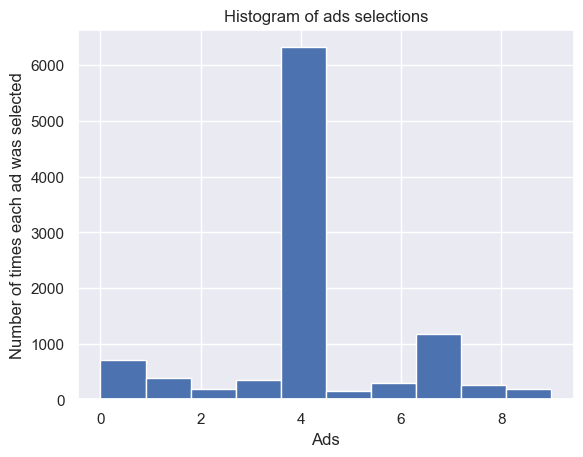

In [15]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()